In [148]:
import numpy as np
from scipy import constants
import pandas as pd
pd.set_option('display.width', 10000) # Adjust for desired width
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # display full content in a column
import matplotlib.pyplot as plt
from tweezer_functions import * 
from IonChainTools import *
from scipy.optimize import fsolve
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar
from scipy.optimize import fsolve
from scipy.optimize import curve_fit
from scipy.optimize import minimize
import matplotlib.ticker as ticker
import itertools
import math

#Constants in SI units
eps0 = constants.epsilon_0 
m = 39.9626*constants.atomic_mass
c = constants.c
e = constants.e
hbar = constants.hbar
pi = np.pi

# setting up parameters that we're not changing
qubit_wavelength = 729e-9
tweezer_wavelength = 532e-9
omega_tweezer = 2*pi*c/tweezer_wavelength
print(omega_tweezer)
df = pd.read_csv("S_P_only.csv",sep = ",",encoding = "UTF-8")
lambdares = np.array(df["wavelength (nm)"])*1e-9
omega_res = 2*pi*c/lambdares
linewidths = np.array(df["A_ki (s^-1)"])
lifetimes = linewidths
print(linewidths)
#test

3540698434791077.0
[1.47e+08 1.40e+08]


In [149]:
f_rf_r = 3e6
f_rf_a = f_rf_r/5

# Parallel optimization, tweezed vs untweezed with defined functions, not optimized power

In [150]:
P_opt = [50e-3]
w0 = 1e-6

results_test_check = []
for Ni in range(2, 8):
    winners = run_optimal_mode_selection_tweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_opt,
        w0,
        max_tweezed=1,
    )
    results_test_check.append((Ni, winners))

untweezed_results = []
# First 5: 1e6 and /3, last 2: 2e6 and /5
f_rf_r_list = np.array([3e6]*6)
f_rf_a_list = [0.3e6]*6
print(f_rf_r_list,f_rf_a_list)
for Ni in range(2,8):
    f_rf_r = f_rf_r_list[Ni-2]
    f_rf_a = f_rf_a_list[Ni-2]
    winners = run_optimal_mode_selection_untweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_opt,
        w0,
    )
    untweezed_results.append((Ni, winners))

untweezed_winners = [untweezed_results[i-2][1][0][2] for i in range(2,8)]

[3000000. 3000000. 3000000. 3000000. 3000000. 3000000.] [300000.0, 300000.0, 300000.0, 300000.0, 300000.0, 300000.0]


In [151]:
untweezed_winners

[0.03956930721333248,
 0.03230820404936569,
 0.02797972545740127,
 0.025025827245812485,
 0.022845350171265322,
 0.02115068437489931]

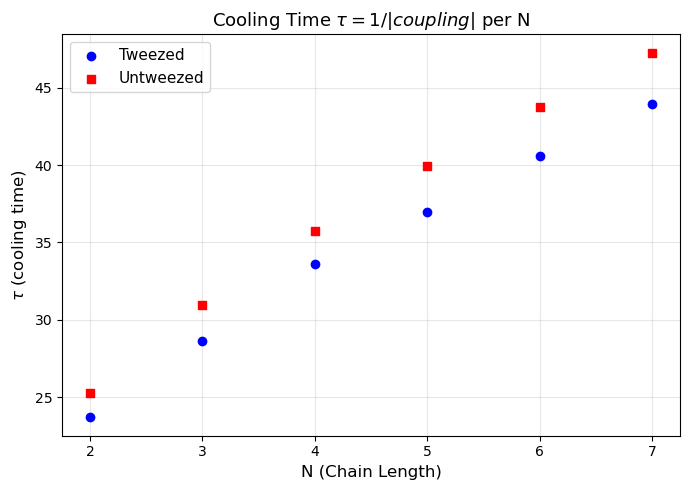

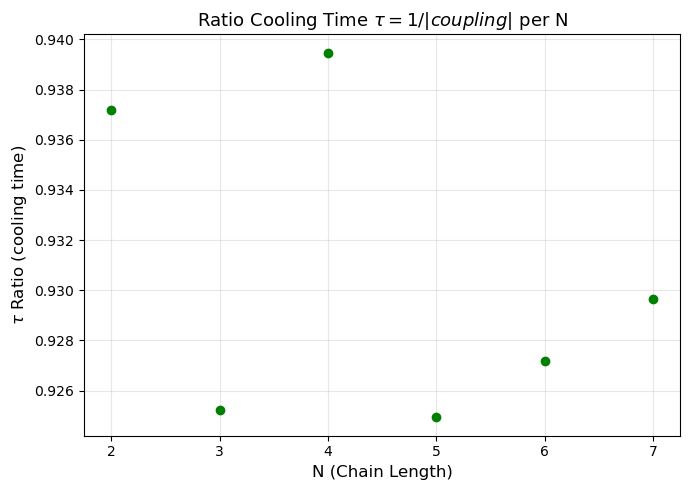

In [152]:
tweezed_data = {}  # {N: score}

for N_val, winners in results_test_check:
    if not winners:
        continue
    
    # Just take the first winner (it's already the best)
    win = winners[0]
    
    # Extract tweezed ion directly
    if isinstance(win, (list, tuple)) and isinstance(win[0], (list, tuple)):
        tweezed_ion = win[0][0]
    else:
        tweezed_ion = win[0]
    
    if tweezed_ion is None:
        continue  # Skip untweezed
    
    # Extract score directly
    if isinstance(win, (list, tuple)) and isinstance(win[0], (list, tuple)) and len(win[0]) >= 3:
        score = win[0][2]
    elif isinstance(win, (list, tuple)) and len(win) >= 3:
        score = win[2]
    else:
        score = None
    
    if score is not None:
        tweezed_data[N_val] = abs(score)

# --- Extract untweezed winning scores (same approach) ---
untweezed_data = {}  # {N: score}

for N_val, winners in untweezed_results:
    if not winners:
        continue
    
    # Just take the first winner
    win = winners[0]
    
    # Extract score directly
    if isinstance(win, (list, tuple)) and isinstance(win[0], (list, tuple)) and len(win[0]) >= 3:
        score = win[0][2]
    elif isinstance(win, (list, tuple)) and len(win) >= 3:
        score = win[2]
    else:
        score = None
    
    if score is not None:
        untweezed_data[N_val] = abs(score)

# --- Prepare arrays for plotting ---
N_tweezed = sorted(tweezed_data.keys())
scores_tweezed = [tweezed_data[N] for N in N_tweezed]

N_untweezed = sorted(untweezed_data.keys())
scores_untweezed = [untweezed_data[N] for N in N_untweezed]

# Convert to 1/score (tau) for better visibility
tau_tweezed = np.array([1.0 / s if s != 0 else np.inf for s in scores_tweezed])
tau_untweezed = np.array([1.0 / s if s != 0 else np.inf for s in scores_untweezed])

# --- Plot ---
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
# Plot : Tau (1/score) for easier interpretation
ax.scatter(N_tweezed, tau_tweezed, marker='o', color='blue', 
            label='Tweezed', zorder=3)
ax.scatter(N_untweezed, tau_untweezed, marker='s', color='red', 
            label='Untweezed', zorder=3)
ax.set_xlabel('N (Chain Length)', fontsize=12)
ax.set_ylabel(r'$\tau$ (cooling time)', fontsize=12)
ax.set_title(r'Cooling Time $\tau = 1/|coupling|$ per N', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

# --- Plot ---
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
# Plot : Tau (1/score) for easier interpretation
ax.scatter(N_tweezed, tau_tweezed/tau_untweezed, marker='o', color='green', 
            zorder=3)
ax.set_xlabel('N (Chain Length)', fontsize=12)
ax.set_ylabel(r'$\tau$ Ratio (cooling time)', fontsize=12)
ax.set_title(r'Ratio Cooling Time $\tau = 1/|coupling|$ per N', fontsize=13)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Power sweep

In [153]:
N_values = np.arange(2,8)
w0 = 1e-6
P_list = np.linspace(1e-6,5,100)  # optical powers from 10 mW to 1 W
# --- Run power sweep using your tweezed-only function ---
power_results = [ [] for _ in N_values]  # List of lists to hold winners for each N
for N in N_values:
    for P in P_list:
        winners = run_optimal_mode_selection_tweezed_only(
            omega_tweezer,
            linewidths,
            omega_res,
            m,
            mode_calc_r,
            N,
            f_rf_r,
            f_rf_a,
            P,
            w0,
            max_tweezed=1
        )
        power_results[N-2].append(winners)


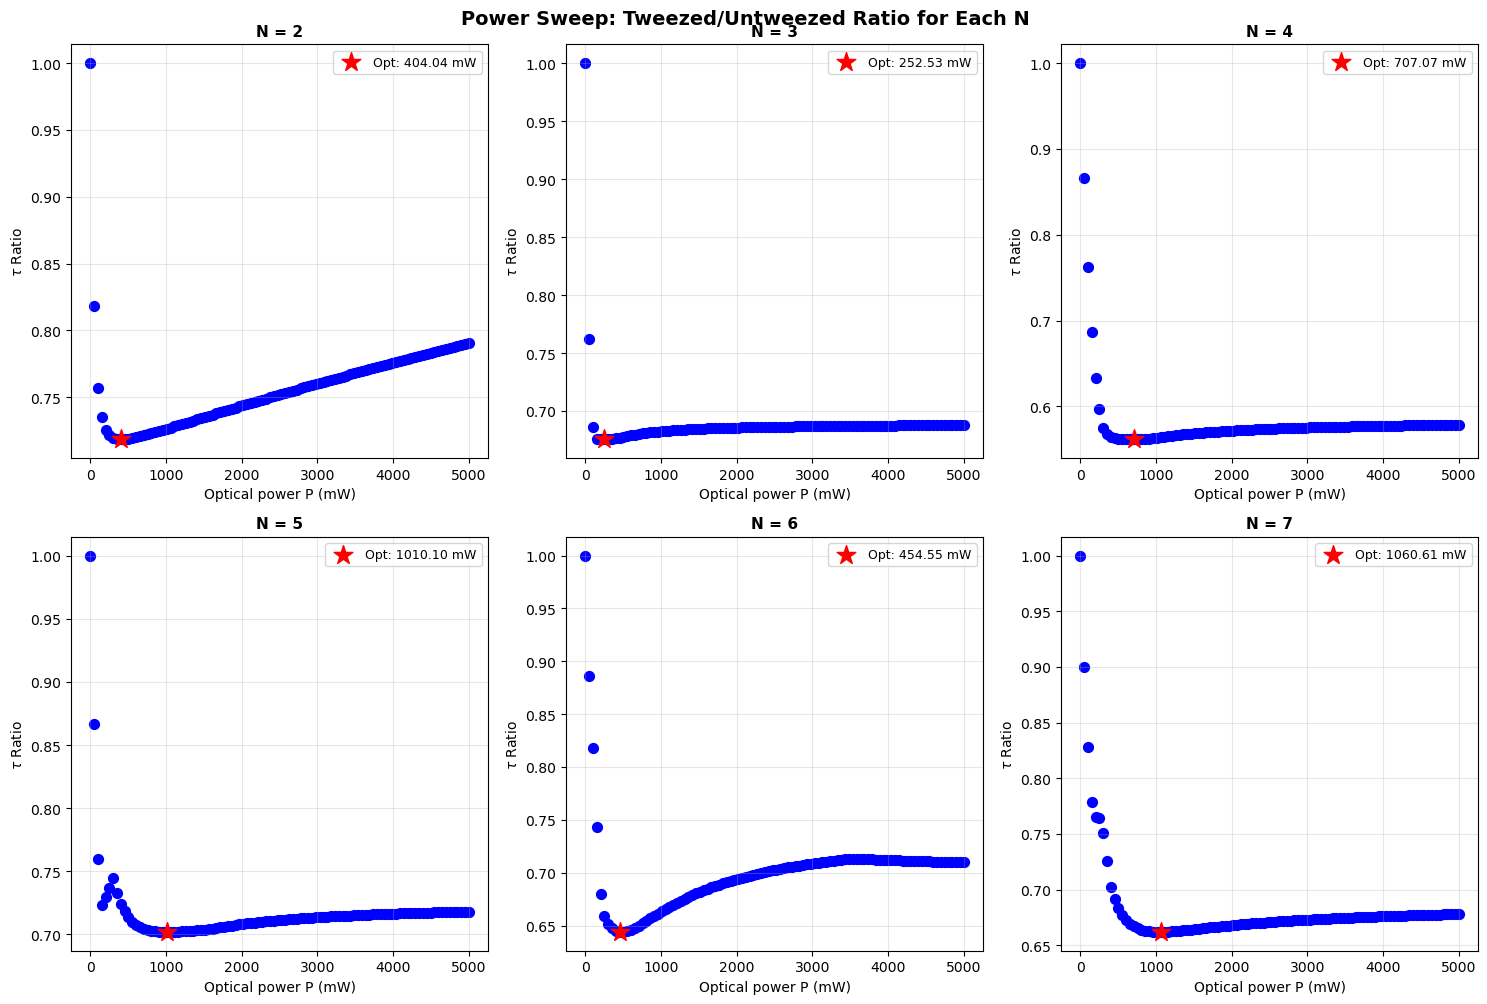


Optimal Powers Summary:
N = 2: P_opt = 4.040413e-01 W = 404.0413 mW,  Ratio = 0.7185
N = 3: P_opt = 2.525262e-01 W = 252.5262 mW,  Ratio = 0.6755
N = 4: P_opt = 7.070716e-01 W = 707.0716 mW,  Ratio = 0.5616
N = 5: P_opt = 1.010102e+00 W = 1010.1018 mW,  Ratio = 0.7020
N = 6: P_opt = 4.545464e-01 W = 454.5464 mW,  Ratio = 0.6439
N = 7: P_opt = 1.060607e+00 W = 1060.6068 mW,  Ratio = 0.6620


In [ ]:
# --- Extract and plot for each N ---
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

optimal_powers_W = []
optimal_powers_mW = []
optimal_ratios = []

f_rf_r_list = np.array([3e6]*6)
f_rf_a_list = [0.3e6]*6
print(f_rf_r_list,f_rf_a_list)
for Ni in range(2,8):
    f_rf_r = f_rf_r_list[Ni-2]
    f_rf_a = f_rf_a_list[Ni-2]
    winners = run_optimal_mode_selection_untweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_opt,
        w0,
    )
    untweezed_results.append((Ni, winners))

untweezed_winners = [untweezed_results[i-2][1][0][2] for i in range(2,8)]

for idx, N in enumerate(N_values):
    x_tweezed = []
    y_tweezed = []
    
    # Extract scores from power_results for this N
    for P_opt, winners in zip(P_list, power_results[N-2]):
        if not winners:
            continue
        winner = winners[0]
        
        if len(winner) >= 3:
            tweezed_ion = winner[0]
            score = winner[2]
        else:
            continue
        
        if tweezed_ion is None:
            continue
        
        x_tweezed.append(P_opt)
        y_tweezed.append(abs(score))
    
    x_tweezed = np.array(x_tweezed)
    y_tweezed = np.array(y_tweezed)
    
    untweezed_ref = untweezed_winners[N-2]
    
    if len(y_tweezed) > 0:
        ratio = untweezed_ref / y_tweezed
        opt_idx = np.argmin(ratio)
        
        opt_power_W = x_tweezed[opt_idx]
        opt_power_mW = opt_power_W * 1e3
        opt_ratio = ratio[opt_idx]
        
        optimal_powers_W.append(opt_power_W)
        optimal_powers_mW.append(opt_power_mW)
        optimal_ratios.append(opt_ratio)
        
        # Plot
        axes[idx].scatter(x_tweezed * 1e3, ratio, marker='o', color='blue', s=50)
        axes[idx].set_xlabel("Optical power P (mW)", fontsize=10)
        axes[idx].set_ylabel(r"$\tau$ Ratio", fontsize=10)
        axes[idx].set_title(f"N = {N}", fontsize=11, fontweight='bold')
        axes[idx].grid(True, alpha=0.3)
        
        axes[idx].scatter(opt_power_mW, opt_ratio, color='red', s=200, marker='*', 
                         zorder=5, label=f'Opt: {opt_power_mW:.2f} mW')
        axes[idx].legend(fontsize=9)

plt.tight_layout()
plt.suptitle("Power Sweep: Tweezed/Untweezed Ratio for Each N", 
             fontsize=14, fontweight='bold', y=1.00)
plt.show()

# --- Print summary (AFTER loop completes) ---
optimal_powers_W = np.array(optimal_powers_W)
optimal_powers_mW = np.array(optimal_powers_mW)
optimal_ratios = np.array(optimal_ratios)

print("\nOptimal Powers Summary:")
print("=" * 60)
for N, P_W, P_mW, ratio in zip(N_values, optimal_powers_W, optimal_powers_mW, optimal_ratios):
    print(f"N = {N}: P_opt = {P_W:.6e} W = {P_mW:.4f} mW,  Ratio = {ratio:.4f}")
print("=" * 60)

## Finding the optimum tweezer frequency to trap frequency ratios from the above 

In [155]:
f_rf_a_list 

[300000.0, 300000.0, 300000.0, 300000.0, 300000.0, 300000.0]

In [156]:
U = potential(omega_tweezer,linewidths,omega_res,1,w0)
tweezer_f = omega_tweezer_r(U,w0,m)/(2.0*pi)
print(tweezer_f/1e6)

1.0098703958516897


In [ ]:
ratio_a = []
ratio_r = []
for P,f_a,f_r in zip(optimal_powers_W,f_rf_a_list,f_rf_r_list):
    U = potential(omega_tweezer,linewidths,omega_res,P,w0)
    tweezer_f = omega_tweezer_r(U,w0,m)/(2.0*pi)
    tweezer_to_rf_a_ratio = tweezer_f / f_a
    tweezer_to_rf_r_ratio = tweezer_f / f_r
    ratio_a.append(tweezer_to_rf_a_ratio)
    ratio_r.append(tweezer_to_rf_r_ratio)


0.641916491799579
0.5074799222304321
0.8491752495208664
1.0149583372500435
0.6808551628430506
1.0400227866153369


In [160]:
ratio_a

[2.13972163933193,
 1.6915997407681072,
 2.830584165069555,
 3.3831944575001445,
 2.269517209476835,
 3.466742622051123]

f_rf_r_list: [1000000.0, 2000000.0, 3000000.0]
f_rf_a_list: [300000.0, 300000.0, 300000.0]

Processing f_rf_r = 1.0 MHz, f_rf_a = 0.300 MHz



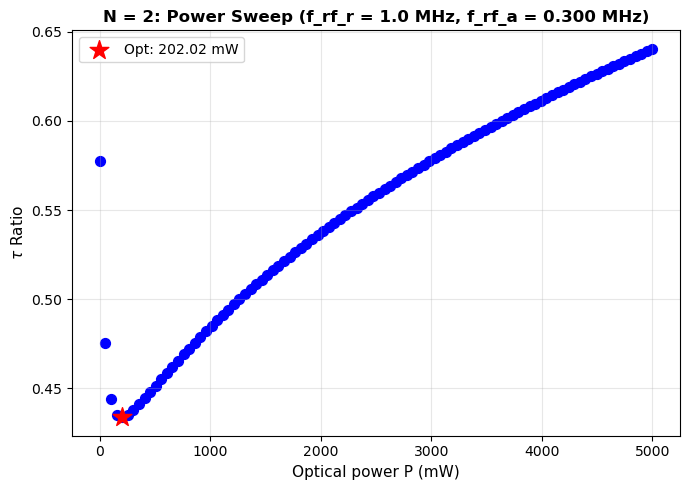


Optimal Powers Summary (f_rf_r = 1.0 MHz):
N = 2: P_opt = 2.020212e-01 W = 202.0212 mW,  Ratio = 0.4338
         f_tweezer/f_rf_a = 1.513014,  f_tweezer/f_rf_r = 0.453904

Processing f_rf_r = 2.0 MHz, f_rf_a = 0.300 MHz



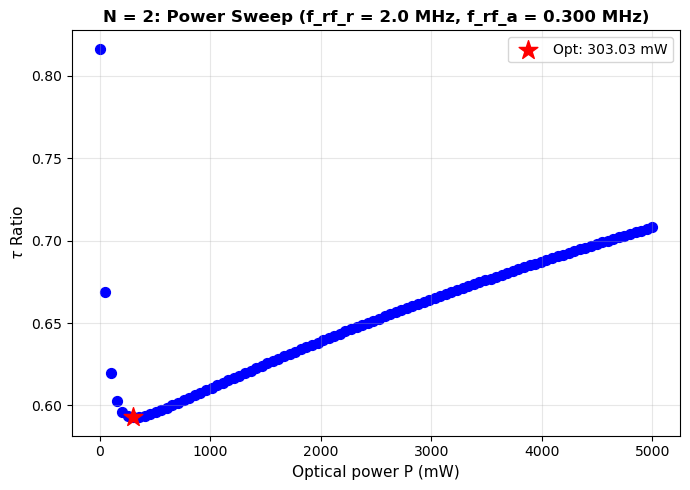


Optimal Powers Summary (f_rf_r = 2.0 MHz):
N = 2: P_opt = 3.030312e-01 W = 303.0312 mW,  Ratio = 0.5928
         f_tweezer/f_rf_a = 1.853054,  f_tweezer/f_rf_r = 0.277958

Processing f_rf_r = 3.0 MHz, f_rf_a = 0.300 MHz



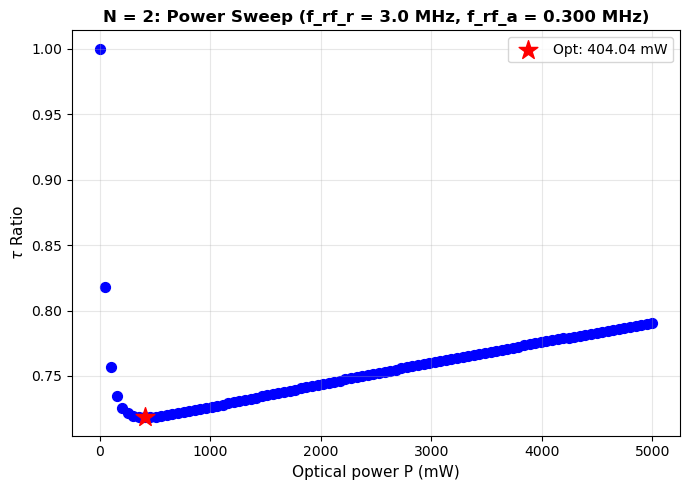


Optimal Powers Summary (f_rf_r = 3.0 MHz):
N = 2: P_opt = 4.040413e-01 W = 404.0413 mW,  Ratio = 0.7185
         f_tweezer/f_rf_a = 2.139722,  f_tweezer/f_rf_r = 0.213972


In [177]:
# --- Create RF frequency lists ---
f_rf_r_list = [1e6, 2e6, 3e6]
f_rf_a_list = [0.3e6, 0.3e6, 0.3e6]  # Match each f_rf_r with corresponding f_rf_a

print(f"f_rf_r_list: {f_rf_r_list}")
print(f"f_rf_a_list: {f_rf_a_list}")

# Loop over each RF frequency pair
for f_idx, (f_rf_r, f_rf_a) in enumerate(zip(f_rf_r_list, f_rf_a_list)):
    print(f"\n{'='*80}")
    print(f"Processing f_rf_r = {f_rf_r/1e6:.1f} MHz, f_rf_a = {f_rf_a/1e6:.3f} MHz")
    print(f"{'='*80}\n")
    
    # --- Extract and plot for each N ---
    fig, ax = plt.subplots(figsize=(7, 5))
    
    N_values = np.arange(2, 3)
    w0 = 1e-6
    P_list = np.linspace(1e-6, 5, 100)  # optical powers
    
    optimal_powers_W = []
    optimal_powers_mW = []
    optimal_ratios = []
    ratio_a = []
    ratio_r = []
    
    for idx, N in enumerate(N_values):
        # --- Run power sweep for this N with current RF frequencies ---
        power_results = []
        for P in P_list:
            winners = run_optimal_mode_selection_tweezed_only(
                omega_tweezer,
                linewidths,
                omega_res,
                m,
                mode_calc_r,
                N,
                f_rf_r,
                f_rf_a,
                P,
                w0,
                max_tweezed=1
            )
            power_results.append(winners)
        
        x_tweezed = []
        y_tweezed = []
        
        # Extract scores from power_results for this N
        for P_opt, winners in zip(P_list, power_results):
            if not winners:
                continue
            winner = winners[0]
            
            if len(winner) >= 3:
                tweezed_ion = winner[0]
                score = winner[2]
            else:
                continue
            
            if tweezed_ion is None:
                continue
            
            x_tweezed.append(P_opt)
            y_tweezed.append(abs(score))
        
        x_tweezed = np.array(x_tweezed)
        y_tweezed = np.array(y_tweezed)
        
        untweezed_ref = untweezed_winners[N-2]
        
        if len(y_tweezed) > 0:
            ratio = untweezed_ref / y_tweezed
            opt_idx = np.argmin(ratio)
            
            opt_power_W = x_tweezed[opt_idx]
            opt_power_mW = opt_power_W * 1e3
            opt_ratio = ratio[opt_idx]
            
            optimal_powers_W.append(opt_power_W)
            optimal_powers_mW.append(opt_power_mW)
            optimal_ratios.append(opt_ratio)
            
            # Calculate tweezer frequency ratios for this N
            U = potential(omega_tweezer, linewidths, omega_res, opt_power_W, w0)
            tweezer_f = omega_tweezer_r(U, w0, m) / (2.0 * pi)
            
            tweezer_to_rf_a_ratio = tweezer_f / f_rf_a
            tweezer_to_rf_r_ratio = tweezer_f / f_rf_r
            
            ratio_a.append(tweezer_to_rf_a_ratio)
            ratio_r.append(tweezer_to_rf_r_ratio)
            
            # Plot on single axis
            ax.scatter(x_tweezed * 1e3, ratio, marker='o', color='blue', s=50)
            ax.set_xlabel("Optical power P (mW)", fontsize=11)
            ax.set_ylabel(r"$\tau$ Ratio", fontsize=11)
            ax.set_title(f"N = {N}: Power Sweep (f_rf_r = {f_rf_r/1e6:.1f} MHz, f_rf_a = {f_rf_a/1e6:.3f} MHz)", 
                        fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)
            
            ax.scatter(opt_power_mW, opt_ratio, color='red', s=200, marker='*', 
                      zorder=5, label=f'Opt: {opt_power_mW:.2f} mW')
            ax.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # --- Print summary for this RF frequency set ---
    optimal_powers_W = np.array(optimal_powers_W)
    optimal_powers_mW = np.array(optimal_powers_mW)
    optimal_ratios = np.array(optimal_ratios)
    ratio_a = np.array(ratio_a)
    ratio_r = np.array(ratio_r)
    
    print(f"\nOptimal Powers Summary (f_rf_r = {f_rf_r/1e6:.1f} MHz):")
    print("=" * 80)
    for N, P_W, P_mW, ratio, r_a, r_r in zip(N_values, optimal_powers_W, optimal_powers_mW, optimal_ratios, ratio_a, ratio_r):
        print(f"N = {N}: P_opt = {P_W:.6e} W = {P_mW:.4f} mW,  Ratio = {ratio:.4f}")
        print(f"         f_tweezer/f_rf_a = {r_a:.6f},  f_tweezer/f_rf_r = {r_r:.6f}")
    print("=" * 80)
    
ratio_a_2 = ratio_a
ratio_r_2 = ratio_r

f_rf_r_list: [1000000.0, 2000000.0, 3000000.0]
f_rf_a_list: [300000.0, 300000.0, 300000.0]

Processing f_rf_r = 1.0 MHz, f_rf_a = 0.300 MHz



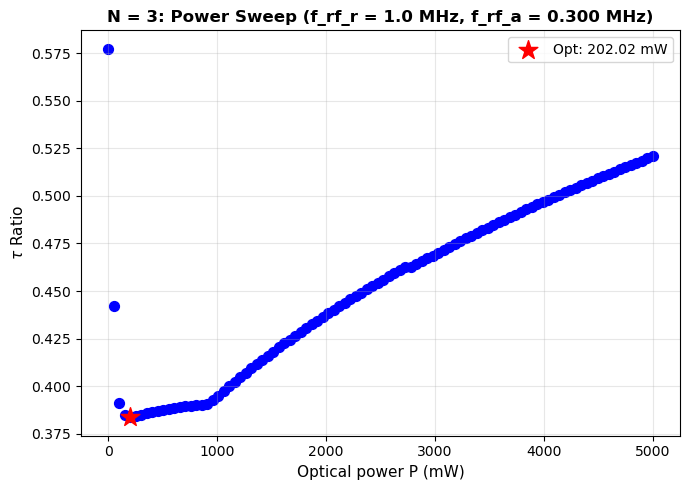


Optimal Powers Summary (f_rf_r = 1.0 MHz):
N = 3: P_opt = 2.020212e-01 W = 202.0212 mW,  Ratio = 0.3836
         f_tweezer/f_rf_a = 1.513014,  f_tweezer/f_rf_r = 0.453904

Processing f_rf_r = 2.0 MHz, f_rf_a = 0.300 MHz



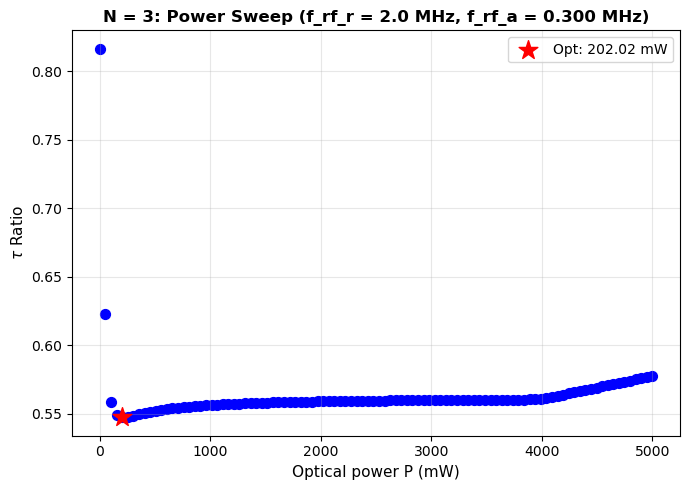


Optimal Powers Summary (f_rf_r = 2.0 MHz):
N = 3: P_opt = 2.020212e-01 W = 202.0212 mW,  Ratio = 0.5476
         f_tweezer/f_rf_a = 1.513014,  f_tweezer/f_rf_r = 0.226952

Processing f_rf_r = 3.0 MHz, f_rf_a = 0.300 MHz



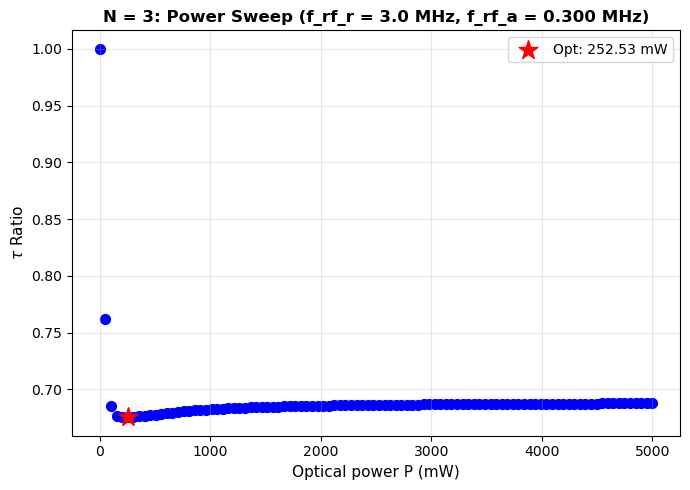


Optimal Powers Summary (f_rf_r = 3.0 MHz):
N = 3: P_opt = 2.525262e-01 W = 252.5262 mW,  Ratio = 0.6755
         f_tweezer/f_rf_a = 1.691600,  f_tweezer/f_rf_r = 0.169160


In [178]:
# --- Create RF frequency lists ---
f_rf_r_list = [1e6, 2e6, 3e6]
f_rf_a_list = [0.3e6, 0.3e6, 0.3e6]  # Match each f_rf_r with corresponding f_rf_a

print(f"f_rf_r_list: {f_rf_r_list}")
print(f"f_rf_a_list: {f_rf_a_list}")

# Loop over each RF frequency pair
for f_idx, (f_rf_r, f_rf_a) in enumerate(zip(f_rf_r_list, f_rf_a_list)):
    print(f"\n{'='*80}")
    print(f"Processing f_rf_r = {f_rf_r/1e6:.1f} MHz, f_rf_a = {f_rf_a/1e6:.3f} MHz")
    print(f"{'='*80}\n")
    
    # --- Extract and plot for each N ---
    fig, ax = plt.subplots(figsize=(7, 5))
    
    N_values = np.arange(3, 4)
    w0 = 1e-6
    P_list = np.linspace(1e-6, 5, 100)  # optical powers
    
    optimal_powers_W = []
    optimal_powers_mW = []
    optimal_ratios = []
    ratio_a = []
    ratio_r = []
    
    for idx, N in enumerate(N_values):
        # --- Run power sweep for this N with current RF frequencies ---
        power_results = []
        for P in P_list:
            winners = run_optimal_mode_selection_tweezed_only(
                omega_tweezer,
                linewidths,
                omega_res,
                m,
                mode_calc_r,
                N,
                f_rf_r,
                f_rf_a,
                P,
                w0,
                max_tweezed=1
            )
            power_results.append(winners)
        
        x_tweezed = []
        y_tweezed = []
        
        # Extract scores from power_results for this N
        for P_opt, winners in zip(P_list, power_results):
            if not winners:
                continue
            winner = winners[0]
            
            if len(winner) >= 3:
                tweezed_ion = winner[0]
                score = winner[2]
            else:
                continue
            
            if tweezed_ion is None:
                continue
            
            x_tweezed.append(P_opt)
            y_tweezed.append(abs(score))
        
        x_tweezed = np.array(x_tweezed)
        y_tweezed = np.array(y_tweezed)
        
        untweezed_ref = untweezed_winners[N-2]
        
        if len(y_tweezed) > 0:
            ratio = untweezed_ref / y_tweezed
            opt_idx = np.argmin(ratio)
            
            opt_power_W = x_tweezed[opt_idx]
            opt_power_mW = opt_power_W * 1e3
            opt_ratio = ratio[opt_idx]
            
            optimal_powers_W.append(opt_power_W)
            optimal_powers_mW.append(opt_power_mW)
            optimal_ratios.append(opt_ratio)
            
            # Calculate tweezer frequency ratios for this N
            U = potential(omega_tweezer, linewidths, omega_res, opt_power_W, w0)
            tweezer_f = omega_tweezer_r(U, w0, m) / (2.0 * pi)
            
            tweezer_to_rf_a_ratio = tweezer_f / f_rf_a
            tweezer_to_rf_r_ratio = tweezer_f / f_rf_r
            
            ratio_a.append(tweezer_to_rf_a_ratio)
            ratio_r.append(tweezer_to_rf_r_ratio)
            
            # Plot on single axis
            ax.scatter(x_tweezed * 1e3, ratio, marker='o', color='blue', s=50)
            ax.set_xlabel("Optical power P (mW)", fontsize=11)
            ax.set_ylabel(r"$\tau$ Ratio", fontsize=11)
            ax.set_title(f"N = {N}: Power Sweep (f_rf_r = {f_rf_r/1e6:.1f} MHz, f_rf_a = {f_rf_a/1e6:.3f} MHz)", 
                        fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)
            
            ax.scatter(opt_power_mW, opt_ratio, color='red', s=200, marker='*', 
                      zorder=5, label=f'Opt: {opt_power_mW:.2f} mW')
            ax.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # --- Print summary for this RF frequency set ---
    optimal_powers_W = np.array(optimal_powers_W)
    optimal_powers_mW = np.array(optimal_powers_mW)
    optimal_ratios = np.array(optimal_ratios)
    ratio_a = np.array(ratio_a)
    ratio_r = np.array(ratio_r)
    
    print(f"\nOptimal Powers Summary (f_rf_r = {f_rf_r/1e6:.1f} MHz):")
    print("=" * 80)
    for N, P_W, P_mW, ratio, r_a, r_r in zip(N_values, optimal_powers_W, optimal_powers_mW, optimal_ratios, ratio_a, ratio_r):
        print(f"N = {N}: P_opt = {P_W:.6e} W = {P_mW:.4f} mW,  Ratio = {ratio:.4f}")
        print(f"         f_tweezer/f_rf_a = {r_a:.6f},  f_tweezer/f_rf_r = {r_r:.6f}")
    print("=" * 80)
ratio_a_3 = ratio_a
ratio_r_3 = ratio_r

f_rf_r_list: [1000000.0, 2000000.0, 3000000.0]
f_rf_a_list: [300000.0, 300000.0, 300000.0]

Processing f_rf_r = 1.0 MHz, f_rf_a = 0.300 MHz



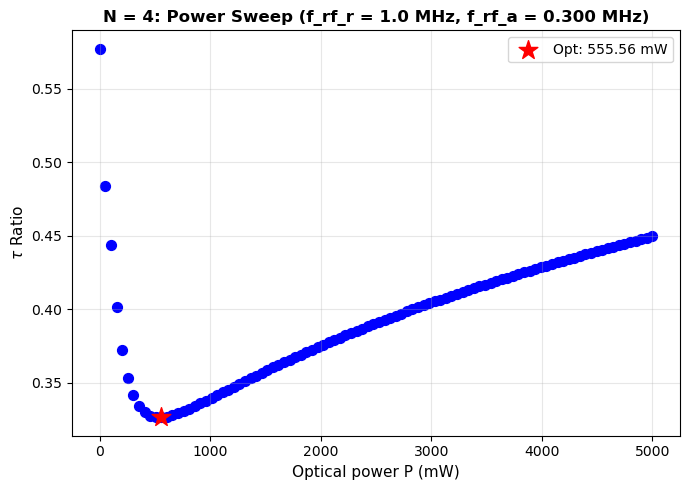


Optimal Powers Summary (f_rf_r = 1.0 MHz):
N = 4: P_opt = 5.555564e-01 W = 555.5564 mW,  Ratio = 0.3266
         f_tweezer/f_rf_a = 2.509045,  f_tweezer/f_rf_r = 0.752714

Processing f_rf_r = 2.0 MHz, f_rf_a = 0.300 MHz



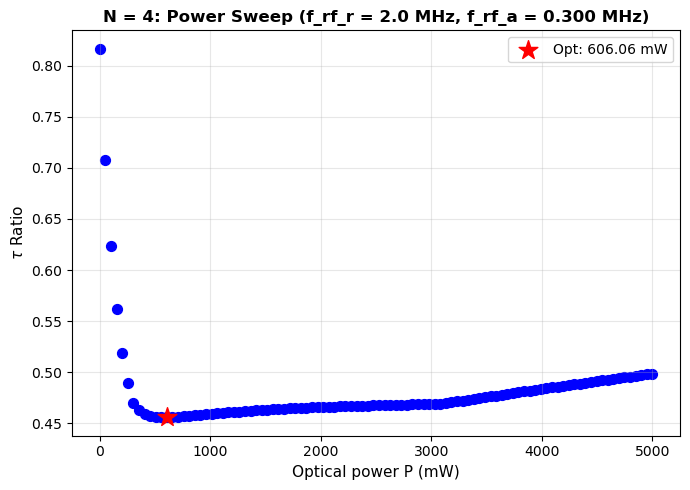


Optimal Powers Summary (f_rf_r = 2.0 MHz):
N = 4: P_opt = 6.060615e-01 W = 606.0615 mW,  Ratio = 0.4559
         f_tweezer/f_rf_a = 2.620612,  f_tweezer/f_rf_r = 0.393092

Processing f_rf_r = 3.0 MHz, f_rf_a = 0.300 MHz



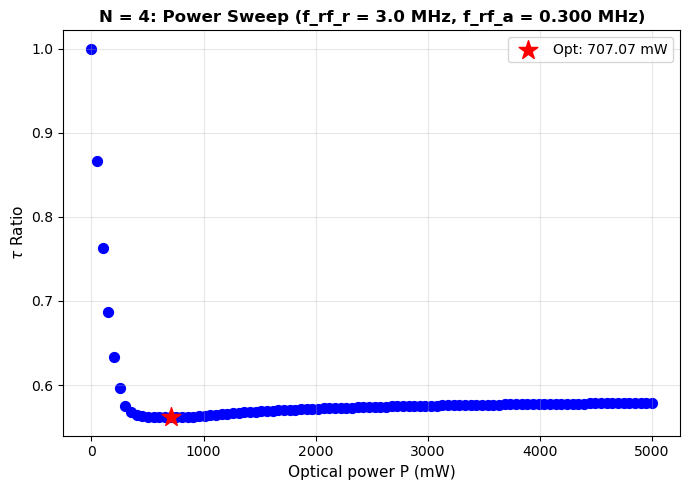


Optimal Powers Summary (f_rf_r = 3.0 MHz):
N = 4: P_opt = 7.070716e-01 W = 707.0716 mW,  Ratio = 0.5616
         f_tweezer/f_rf_a = 2.830584,  f_tweezer/f_rf_r = 0.283058


In [179]:
# --- Create RF frequency lists ---
f_rf_r_list = [1e6, 2e6, 3e6]
f_rf_a_list = [0.3e6, 0.3e6, 0.3e6]  # Match each f_rf_r with corresponding f_rf_a

print(f"f_rf_r_list: {f_rf_r_list}")
print(f"f_rf_a_list: {f_rf_a_list}")

# Loop over each RF frequency pair
for f_idx, (f_rf_r, f_rf_a) in enumerate(zip(f_rf_r_list, f_rf_a_list)):
    print(f"\n{'='*80}")
    print(f"Processing f_rf_r = {f_rf_r/1e6:.1f} MHz, f_rf_a = {f_rf_a/1e6:.3f} MHz")
    print(f"{'='*80}\n")
    
    # --- Extract and plot for each N ---
    fig, ax = plt.subplots(figsize=(7, 5))
    
    N_values = np.arange(4, 5)
    w0 = 1e-6
    P_list = np.linspace(1e-6, 5, 100)  # optical powers
    
    optimal_powers_W = []
    optimal_powers_mW = []
    optimal_ratios = []
    ratio_a = []
    ratio_r = []
    
    for idx, N in enumerate(N_values):
        # --- Run power sweep for this N with current RF frequencies ---
        power_results = []
        for P in P_list:
            winners = run_optimal_mode_selection_tweezed_only(
                omega_tweezer,
                linewidths,
                omega_res,
                m,
                mode_calc_r,
                N,
                f_rf_r,
                f_rf_a,
                P,
                w0,
                max_tweezed=1
            )
            power_results.append(winners)
        
        x_tweezed = []
        y_tweezed = []
        
        # Extract scores from power_results for this N
        for P_opt, winners in zip(P_list, power_results):
            if not winners:
                continue
            winner = winners[0]
            
            if len(winner) >= 3:
                tweezed_ion = winner[0]
                score = winner[2]
            else:
                continue
            
            if tweezed_ion is None:
                continue
            
            x_tweezed.append(P_opt)
            y_tweezed.append(abs(score))
        
        x_tweezed = np.array(x_tweezed)
        y_tweezed = np.array(y_tweezed)
        
        untweezed_ref = untweezed_winners[N-2]
        
        if len(y_tweezed) > 0:
            ratio = untweezed_ref / y_tweezed
            opt_idx = np.argmin(ratio)
            
            opt_power_W = x_tweezed[opt_idx]
            opt_power_mW = opt_power_W * 1e3
            opt_ratio = ratio[opt_idx]
            
            optimal_powers_W.append(opt_power_W)
            optimal_powers_mW.append(opt_power_mW)
            optimal_ratios.append(opt_ratio)
            
            # Calculate tweezer frequency ratios for this N
            U = potential(omega_tweezer, linewidths, omega_res, opt_power_W, w0)
            tweezer_f = omega_tweezer_r(U, w0, m) / (2.0 * pi)
            
            tweezer_to_rf_a_ratio = tweezer_f / f_rf_a
            tweezer_to_rf_r_ratio = tweezer_f / f_rf_r
            
            ratio_a.append(tweezer_to_rf_a_ratio)
            ratio_r.append(tweezer_to_rf_r_ratio)
            
            # Plot on single axis
            ax.scatter(x_tweezed * 1e3, ratio, marker='o', color='blue', s=50)
            ax.set_xlabel("Optical power P (mW)", fontsize=11)
            ax.set_ylabel(r"$\tau$ Ratio", fontsize=11)
            ax.set_title(f"N = {N}: Power Sweep (f_rf_r = {f_rf_r/1e6:.1f} MHz, f_rf_a = {f_rf_a/1e6:.3f} MHz)", 
                        fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)
            
            ax.scatter(opt_power_mW, opt_ratio, color='red', s=200, marker='*', 
                      zorder=5, label=f'Opt: {opt_power_mW:.2f} mW')
            ax.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # --- Print summary for this RF frequency set ---
    optimal_powers_W = np.array(optimal_powers_W)
    optimal_powers_mW = np.array(optimal_powers_mW)
    optimal_ratios = np.array(optimal_ratios)
    ratio_a = np.array(ratio_a)
    ratio_r = np.array(ratio_r)
    
    print(f"\nOptimal Powers Summary (f_rf_r = {f_rf_r/1e6:.1f} MHz):")
    print("=" * 80)
    for N, P_W, P_mW, ratio, r_a, r_r in zip(N_values, optimal_powers_W, optimal_powers_mW, optimal_ratios, ratio_a, ratio_r):
        print(f"N = {N}: P_opt = {P_W:.6e} W = {P_mW:.4f} mW,  Ratio = {ratio:.4f}")
        print(f"         f_tweezer/f_rf_a = {r_a:.6f},  f_tweezer/f_rf_r = {r_r:.6f}")
    print("=" * 80)
ratio_a_4 = ratio_a
ratio_r_4 = ratio_r    

f_rf_r_list: [1000000.0, 2000000.0, 3000000.0]
f_rf_a_list: [300000.0, 300000.0, 300000.0]

Processing f_rf_r = 1.0 MHz, f_rf_a = 0.300 MHz



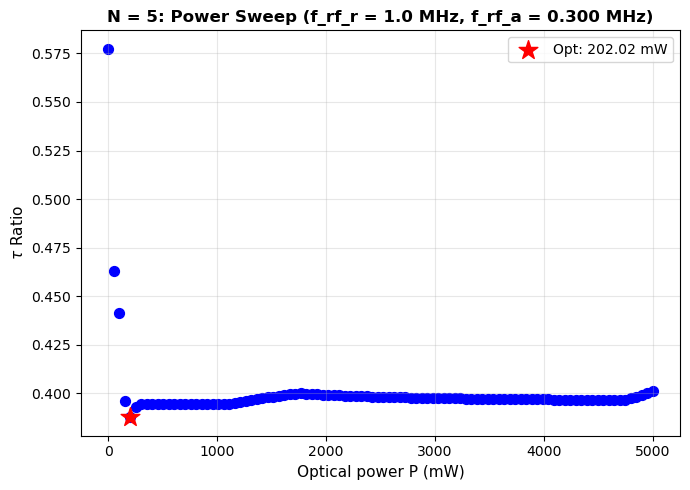


Optimal Powers Summary (f_rf_r = 1.0 MHz):
N = 5: P_opt = 2.020212e-01 W = 202.0212 mW,  Ratio = 0.3877
         f_tweezer/f_rf_a = 1.513014,  f_tweezer/f_rf_r = 0.453904

Processing f_rf_r = 2.0 MHz, f_rf_a = 0.300 MHz



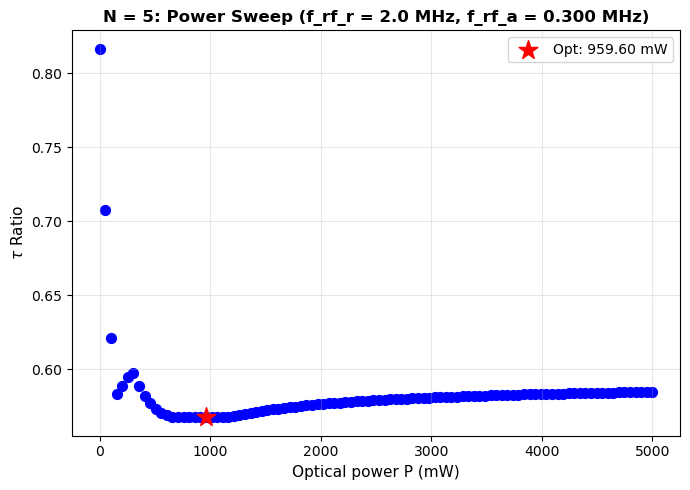


Optimal Powers Summary (f_rf_r = 2.0 MHz):
N = 5: P_opt = 9.595968e-01 W = 959.5968 mW,  Ratio = 0.5677
         f_tweezer/f_rf_a = 3.297530,  f_tweezer/f_rf_r = 0.494630

Processing f_rf_r = 3.0 MHz, f_rf_a = 0.300 MHz



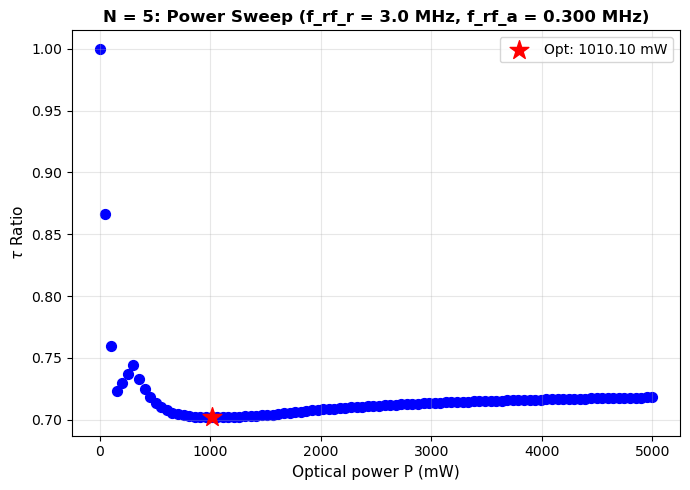


Optimal Powers Summary (f_rf_r = 3.0 MHz):
N = 5: P_opt = 1.010102e+00 W = 1010.1018 mW,  Ratio = 0.7020
         f_tweezer/f_rf_a = 3.383194,  f_tweezer/f_rf_r = 0.338319


In [180]:
# --- Create RF frequency lists ---
f_rf_r_list = [1e6, 2e6, 3e6]
f_rf_a_list = [0.3e6, 0.3e6, 0.3e6]  # Match each f_rf_r with corresponding f_rf_a

print(f"f_rf_r_list: {f_rf_r_list}")
print(f"f_rf_a_list: {f_rf_a_list}")

# Loop over each RF frequency pair
for f_idx, (f_rf_r, f_rf_a) in enumerate(zip(f_rf_r_list, f_rf_a_list)):
    print(f"\n{'='*80}")
    print(f"Processing f_rf_r = {f_rf_r/1e6:.1f} MHz, f_rf_a = {f_rf_a/1e6:.3f} MHz")
    print(f"{'='*80}\n")
    
    # --- Extract and plot for each N ---
    fig, ax = plt.subplots(figsize=(7, 5))
    
    N_values = np.arange(5, 6)
    w0 = 1e-6
    P_list = np.linspace(1e-6, 5, 100)  # optical powers
    
    optimal_powers_W = []
    optimal_powers_mW = []
    optimal_ratios = []
    ratio_a = []
    ratio_r = []
    
    for idx, N in enumerate(N_values):
        # --- Run power sweep for this N with current RF frequencies ---
        power_results = []
        for P in P_list:
            winners = run_optimal_mode_selection_tweezed_only(
                omega_tweezer,
                linewidths,
                omega_res,
                m,
                mode_calc_r,
                N,
                f_rf_r,
                f_rf_a,
                P,
                w0,
                max_tweezed=1
            )
            power_results.append(winners)
        
        x_tweezed = []
        y_tweezed = []
        
        # Extract scores from power_results for this N
        for P_opt, winners in zip(P_list, power_results):
            if not winners:
                continue
            winner = winners[0]
            
            if len(winner) >= 3:
                tweezed_ion = winner[0]
                score = winner[2]
            else:
                continue
            
            if tweezed_ion is None:
                continue
            
            x_tweezed.append(P_opt)
            y_tweezed.append(abs(score))
        
        x_tweezed = np.array(x_tweezed)
        y_tweezed = np.array(y_tweezed)
        
        untweezed_ref = untweezed_winners[N-2]
        
        if len(y_tweezed) > 0:
            ratio = untweezed_ref / y_tweezed
            opt_idx = np.argmin(ratio)
            
            opt_power_W = x_tweezed[opt_idx]
            opt_power_mW = opt_power_W * 1e3
            opt_ratio = ratio[opt_idx]
            
            optimal_powers_W.append(opt_power_W)
            optimal_powers_mW.append(opt_power_mW)
            optimal_ratios.append(opt_ratio)
            
            # Calculate tweezer frequency ratios for this N
            U = potential(omega_tweezer, linewidths, omega_res, opt_power_W, w0)
            tweezer_f = omega_tweezer_r(U, w0, m) / (2.0 * pi)
            
            tweezer_to_rf_a_ratio = tweezer_f / f_rf_a
            tweezer_to_rf_r_ratio = tweezer_f / f_rf_r
            
            ratio_a.append(tweezer_to_rf_a_ratio)
            ratio_r.append(tweezer_to_rf_r_ratio)
            
            # Plot on single axis
            ax.scatter(x_tweezed * 1e3, ratio, marker='o', color='blue', s=50)
            ax.set_xlabel("Optical power P (mW)", fontsize=11)
            ax.set_ylabel(r"$\tau$ Ratio", fontsize=11)
            ax.set_title(f"N = {N}: Power Sweep (f_rf_r = {f_rf_r/1e6:.1f} MHz, f_rf_a = {f_rf_a/1e6:.3f} MHz)", 
                        fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)
            
            ax.scatter(opt_power_mW, opt_ratio, color='red', s=200, marker='*', 
                      zorder=5, label=f'Opt: {opt_power_mW:.2f} mW')
            ax.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # --- Print summary for this RF frequency set ---
    optimal_powers_W = np.array(optimal_powers_W)
    optimal_powers_mW = np.array(optimal_powers_mW)
    optimal_ratios = np.array(optimal_ratios)
    ratio_a = np.array(ratio_a)
    ratio_r = np.array(ratio_r)
    
    print(f"\nOptimal Powers Summary (f_rf_r = {f_rf_r/1e6:.1f} MHz):")
    print("=" * 80)
    for N, P_W, P_mW, ratio, r_a, r_r in zip(N_values, optimal_powers_W, optimal_powers_mW, optimal_ratios, ratio_a, ratio_r):
        print(f"N = {N}: P_opt = {P_W:.6e} W = {P_mW:.4f} mW,  Ratio = {ratio:.4f}")
        print(f"         f_tweezer/f_rf_a = {r_a:.6f},  f_tweezer/f_rf_r = {r_r:.6f}")
    print("=" * 80)

ratio_a_5 = ratio_a
ratio_r_5 = ratio_r    

f_rf_r_list: [1000000.0, 2000000.0, 3000000.0]
f_rf_a_list: [300000.0, 300000.0, 300000.0]

Processing f_rf_r = 1.0 MHz, f_rf_a = 0.300 MHz



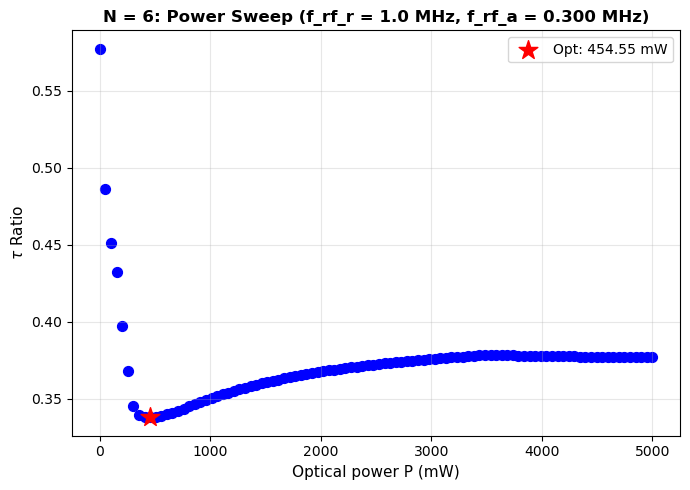


Optimal Powers Summary (f_rf_r = 1.0 MHz):
N = 6: P_opt = 4.545464e-01 W = 454.5464 mW,  Ratio = 0.3379
         f_tweezer/f_rf_a = 2.269517,  f_tweezer/f_rf_r = 0.680855

Processing f_rf_r = 2.0 MHz, f_rf_a = 0.300 MHz



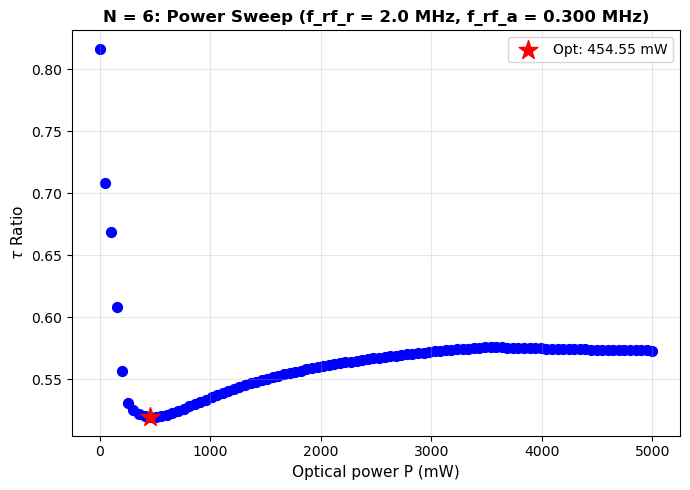


Optimal Powers Summary (f_rf_r = 2.0 MHz):
N = 6: P_opt = 4.545464e-01 W = 454.5464 mW,  Ratio = 0.5191
         f_tweezer/f_rf_a = 2.269517,  f_tweezer/f_rf_r = 0.340428

Processing f_rf_r = 3.0 MHz, f_rf_a = 0.300 MHz



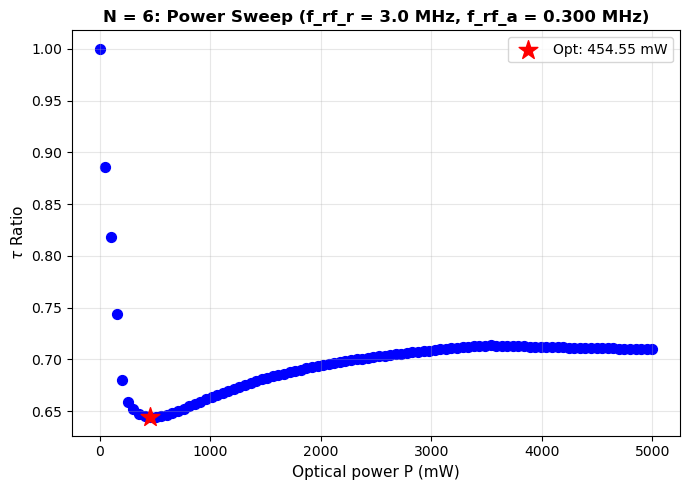


Optimal Powers Summary (f_rf_r = 3.0 MHz):
N = 6: P_opt = 4.545464e-01 W = 454.5464 mW,  Ratio = 0.6439
         f_tweezer/f_rf_a = 2.269517,  f_tweezer/f_rf_r = 0.226952


In [181]:
# --- Create RF frequency lists ---
f_rf_r_list = [1e6, 2e6, 3e6]
f_rf_a_list = [0.3e6, 0.3e6, 0.3e6]  # Match each f_rf_r with corresponding f_rf_a

print(f"f_rf_r_list: {f_rf_r_list}")
print(f"f_rf_a_list: {f_rf_a_list}")

# Loop over each RF frequency pair
for f_idx, (f_rf_r, f_rf_a) in enumerate(zip(f_rf_r_list, f_rf_a_list)):
    print(f"\n{'='*80}")
    print(f"Processing f_rf_r = {f_rf_r/1e6:.1f} MHz, f_rf_a = {f_rf_a/1e6:.3f} MHz")
    print(f"{'='*80}\n")
    
    # --- Extract and plot for each N ---
    fig, ax = plt.subplots(figsize=(7, 5))
    
    N_values = np.arange(6, 7)
    w0 = 1e-6
    P_list = np.linspace(1e-6, 5, 100)  # optical powers
    
    optimal_powers_W = []
    optimal_powers_mW = []
    optimal_ratios = []
    ratio_a = []
    ratio_r = []
    
    for idx, N in enumerate(N_values):
        # --- Run power sweep for this N with current RF frequencies ---
        power_results = []
        for P in P_list:
            winners = run_optimal_mode_selection_tweezed_only(
                omega_tweezer,
                linewidths,
                omega_res,
                m,
                mode_calc_r,
                N,
                f_rf_r,
                f_rf_a,
                P,
                w0,
                max_tweezed=1
            )
            power_results.append(winners)
        
        x_tweezed = []
        y_tweezed = []
        
        # Extract scores from power_results for this N
        for P_opt, winners in zip(P_list, power_results):
            if not winners:
                continue
            winner = winners[0]
            
            if len(winner) >= 3:
                tweezed_ion = winner[0]
                score = winner[2]
            else:
                continue
            
            if tweezed_ion is None:
                continue
            
            x_tweezed.append(P_opt)
            y_tweezed.append(abs(score))
        
        x_tweezed = np.array(x_tweezed)
        y_tweezed = np.array(y_tweezed)
        
        untweezed_ref = untweezed_winners[N-2]
        
        if len(y_tweezed) > 0:
            ratio = untweezed_ref / y_tweezed
            opt_idx = np.argmin(ratio)
            
            opt_power_W = x_tweezed[opt_idx]
            opt_power_mW = opt_power_W * 1e3
            opt_ratio = ratio[opt_idx]
            
            optimal_powers_W.append(opt_power_W)
            optimal_powers_mW.append(opt_power_mW)
            optimal_ratios.append(opt_ratio)
            
            # Calculate tweezer frequency ratios for this N
            U = potential(omega_tweezer, linewidths, omega_res, opt_power_W, w0)
            tweezer_f = omega_tweezer_r(U, w0, m) / (2.0 * pi)
            
            tweezer_to_rf_a_ratio = tweezer_f / f_rf_a
            tweezer_to_rf_r_ratio = tweezer_f / f_rf_r
            
            ratio_a.append(tweezer_to_rf_a_ratio)
            ratio_r.append(tweezer_to_rf_r_ratio)
            
            # Plot on single axis
            ax.scatter(x_tweezed * 1e3, ratio, marker='o', color='blue', s=50)
            ax.set_xlabel("Optical power P (mW)", fontsize=11)
            ax.set_ylabel(r"$\tau$ Ratio", fontsize=11)
            ax.set_title(f"N = {N}: Power Sweep (f_rf_r = {f_rf_r/1e6:.1f} MHz, f_rf_a = {f_rf_a/1e6:.3f} MHz)", 
                        fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)
            
            ax.scatter(opt_power_mW, opt_ratio, color='red', s=200, marker='*', 
                      zorder=5, label=f'Opt: {opt_power_mW:.2f} mW')
            ax.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # --- Print summary for this RF frequency set ---
    optimal_powers_W = np.array(optimal_powers_W)
    optimal_powers_mW = np.array(optimal_powers_mW)
    optimal_ratios = np.array(optimal_ratios)
    ratio_a = np.array(ratio_a)
    ratio_r = np.array(ratio_r)
    
    print(f"\nOptimal Powers Summary (f_rf_r = {f_rf_r/1e6:.1f} MHz):")
    print("=" * 80)
    for N, P_W, P_mW, ratio, r_a, r_r in zip(N_values, optimal_powers_W, optimal_powers_mW, optimal_ratios, ratio_a, ratio_r):
        print(f"N = {N}: P_opt = {P_W:.6e} W = {P_mW:.4f} mW,  Ratio = {ratio:.4f}")
        print(f"         f_tweezer/f_rf_a = {r_a:.6f},  f_tweezer/f_rf_r = {r_r:.6f}")
    print("=" * 80)

ratio_a_6 = ratio_a
ratio_r_6 = ratio_r

f_rf_r_list: [1000000.0, 2000000.0, 3000000.0]
f_rf_a_list: [300000.0, 300000.0, 300000.0]

Processing f_rf_r = 1.0 MHz, f_rf_a = 0.300 MHz



/Users/ritika/SQRL_Rithi_python/BladeRunner/Tweezers/tweezer_functions.py:355: RuntimeWarning: invalid value encountered in sqrt
  freqs =( np.sqrt(1*eigvals/m))/(2*pi) #eigenvalue = spring constant k, so freq = sqrt(e-val)/(2*pi*m)
/Users/ritika/SQRL_Rithi_python/BladeRunner/Tweezers/tweezer_functions.py:355: RuntimeWarning: invalid value encountered in sqrt
  freqs =( np.sqrt(1*eigvals/m))/(2*pi) #eigenvalue = spring constant k, so freq = sqrt(e-val)/(2*pi*m)
/Users/ritika/SQRL_Rithi_python/BladeRunner/Tweezers/tweezer_functions.py:355: RuntimeWarning: invalid value encountered in sqrt
  freqs =( np.sqrt(1*eigvals/m))/(2*pi) #eigenvalue = spring constant k, so freq = sqrt(e-val)/(2*pi*m)
/Users/ritika/SQRL_Rithi_python/BladeRunner/Tweezers/tweezer_functions.py:355: RuntimeWarning: invalid value encountered in sqrt
  freqs =( np.sqrt(1*eigvals/m))/(2*pi) #eigenvalue = spring constant k, so freq = sqrt(e-val)/(2*pi*m)
/Users/ritika/SQRL_Rithi_python/BladeRunner/Tweezers/tweezer_functio

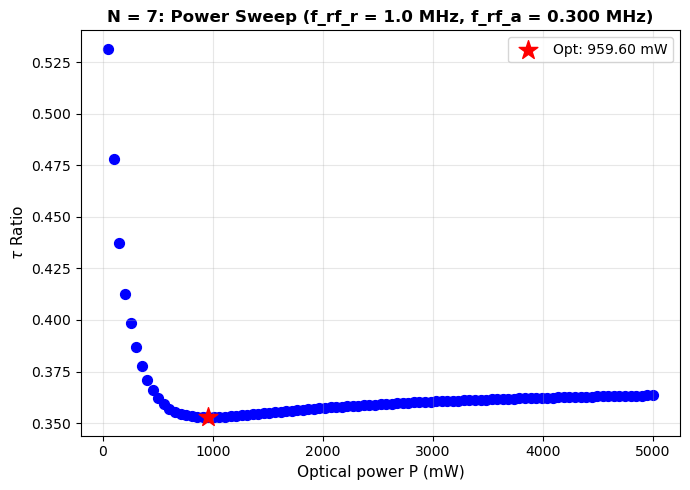


Optimal Powers Summary (f_rf_r = 1.0 MHz):
N = 7: P_opt = 9.595968e-01 W = 959.5968 mW,  Ratio = 0.3528
         f_tweezer/f_rf_a = 3.297530,  f_tweezer/f_rf_r = 0.989259

Processing f_rf_r = 2.0 MHz, f_rf_a = 0.300 MHz



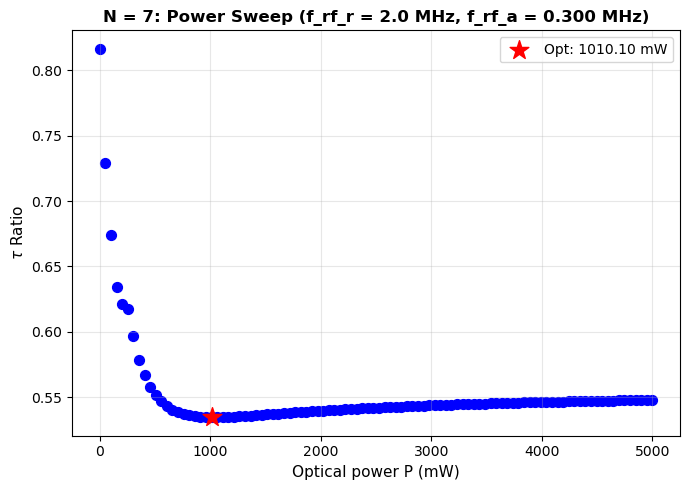


Optimal Powers Summary (f_rf_r = 2.0 MHz):
N = 7: P_opt = 1.010102e+00 W = 1010.1018 mW,  Ratio = 0.5346
         f_tweezer/f_rf_a = 3.383194,  f_tweezer/f_rf_r = 0.507479

Processing f_rf_r = 3.0 MHz, f_rf_a = 0.300 MHz



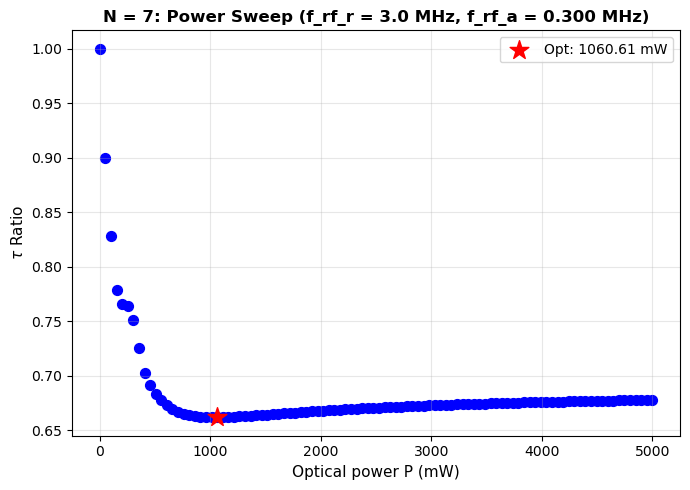


Optimal Powers Summary (f_rf_r = 3.0 MHz):
N = 7: P_opt = 1.060607e+00 W = 1060.6068 mW,  Ratio = 0.6620
         f_tweezer/f_rf_a = 3.466743,  f_tweezer/f_rf_r = 0.346674


In [182]:
# --- Create RF frequency lists ---
f_rf_r_list = [1e6, 2e6, 3e6]
f_rf_a_list = [0.3e6, 0.3e6, 0.3e6]  # Match each f_rf_r with corresponding f_rf_a

print(f"f_rf_r_list: {f_rf_r_list}")
print(f"f_rf_a_list: {f_rf_a_list}")

# Loop over each RF frequency pair
for f_idx, (f_rf_r, f_rf_a) in enumerate(zip(f_rf_r_list, f_rf_a_list)):
    print(f"\n{'='*80}")
    print(f"Processing f_rf_r = {f_rf_r/1e6:.1f} MHz, f_rf_a = {f_rf_a/1e6:.3f} MHz")
    print(f"{'='*80}\n")
    
    # --- Extract and plot for each N ---
    fig, ax = plt.subplots(figsize=(7, 5))
    
    N_values = np.arange(7, 8)
    w0 = 1e-6
    P_list = np.linspace(1e-6, 5, 100)  # optical powers
    
    optimal_powers_W = []
    optimal_powers_mW = []
    optimal_ratios = []
    ratio_a = []
    ratio_r = []
    
    for idx, N in enumerate(N_values):
        # --- Run power sweep for this N with current RF frequencies ---
        power_results = []
        for P in P_list:
            winners = run_optimal_mode_selection_tweezed_only(
                omega_tweezer,
                linewidths,
                omega_res,
                m,
                mode_calc_r,
                N,
                f_rf_r,
                f_rf_a,
                P,
                w0,
                max_tweezed=1
            )
            power_results.append(winners)
        
        x_tweezed = []
        y_tweezed = []
        
        # Extract scores from power_results for this N
        for P_opt, winners in zip(P_list, power_results):
            if not winners:
                continue
            winner = winners[0]
            
            if len(winner) >= 3:
                tweezed_ion = winner[0]
                score = winner[2]
            else:
                continue
            
            if tweezed_ion is None:
                continue
            
            x_tweezed.append(P_opt)
            y_tweezed.append(abs(score))
        
        x_tweezed = np.array(x_tweezed)
        y_tweezed = np.array(y_tweezed)
        
        untweezed_ref = untweezed_winners[N-2]
        
        if len(y_tweezed) > 0:
            ratio = untweezed_ref / y_tweezed
            opt_idx = np.argmin(ratio)
            
            opt_power_W = x_tweezed[opt_idx]
            opt_power_mW = opt_power_W * 1e3
            opt_ratio = ratio[opt_idx]
            
            optimal_powers_W.append(opt_power_W)
            optimal_powers_mW.append(opt_power_mW)
            optimal_ratios.append(opt_ratio)
            
            # Calculate tweezer frequency ratios for this N
            U = potential(omega_tweezer, linewidths, omega_res, opt_power_W, w0)
            tweezer_f = omega_tweezer_r(U, w0, m) / (2.0 * pi)
            
            tweezer_to_rf_a_ratio = tweezer_f / f_rf_a
            tweezer_to_rf_r_ratio = tweezer_f / f_rf_r
            
            ratio_a.append(tweezer_to_rf_a_ratio)
            ratio_r.append(tweezer_to_rf_r_ratio)
            
            # Plot on single axis
            ax.scatter(x_tweezed * 1e3, ratio, marker='o', color='blue', s=50)
            ax.set_xlabel("Optical power P (mW)", fontsize=11)
            ax.set_ylabel(r"$\tau$ Ratio", fontsize=11)
            ax.set_title(f"N = {N}: Power Sweep (f_rf_r = {f_rf_r/1e6:.1f} MHz, f_rf_a = {f_rf_a/1e6:.3f} MHz)", 
                        fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)
            
            ax.scatter(opt_power_mW, opt_ratio, color='red', s=200, marker='*', 
                      zorder=5, label=f'Opt: {opt_power_mW:.2f} mW')
            ax.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # --- Print summary for this RF frequency set ---
    optimal_powers_W = np.array(optimal_powers_W)
    optimal_powers_mW = np.array(optimal_powers_mW)
    optimal_ratios = np.array(optimal_ratios)
    ratio_a = np.array(ratio_a)
    ratio_r = np.array(ratio_r)
    
    print(f"\nOptimal Powers Summary (f_rf_r = {f_rf_r/1e6:.1f} MHz):")
    print("=" * 80)
    for N, P_W, P_mW, ratio, r_a, r_r in zip(N_values, optimal_powers_W, optimal_powers_mW, optimal_ratios, ratio_a, ratio_r):
        print(f"N = {N}: P_opt = {P_W:.6e} W = {P_mW:.4f} mW,  Ratio = {ratio:.4f}")
        print(f"         f_tweezer/f_rf_a = {r_a:.6f},  f_tweezer/f_rf_r = {r_r:.6f}")
    print("=" * 80)

ratio_a_7 = ratio_a
ratio_r_7 = ratio_r

In [183]:
print(ratio_r_2,ratio_r_3,ratio_r_4,ratio_r_5,ratio_r_6,ratio_r_7)

[0.21397216] [0.16915997] [0.28305842] [0.33831945] [0.22695172] [0.34667426]


In [184]:
print(ratio_a_2,ratio_a_3,ratio_a_4,ratio_a_5,ratio_a_6,ratio_a_7)

[2.13972164] [1.69159974] [2.83058417] [3.38319446] [2.26951721] [3.46674262]


f_rf_r_list: [1000000.0, 2000000.0, 3000000.0]
f_rf_a_list: [300000.0, 300000.0, 300000.0]

Processing f_rf_r = 1.0 MHz, f_rf_a = 0.300 MHz



/Users/ritika/SQRL_Rithi_python/BladeRunner/Tweezers/tweezer_functions.py:355: RuntimeWarning: invalid value encountered in sqrt
  freqs =( np.sqrt(1*eigvals/m))/(2*pi) #eigenvalue = spring constant k, so freq = sqrt(e-val)/(2*pi*m)
/Users/ritika/SQRL_Rithi_python/BladeRunner/Tweezers/tweezer_functions.py:355: RuntimeWarning: invalid value encountered in sqrt
  freqs =( np.sqrt(1*eigvals/m))/(2*pi) #eigenvalue = spring constant k, so freq = sqrt(e-val)/(2*pi*m)
/Users/ritika/SQRL_Rithi_python/BladeRunner/Tweezers/tweezer_functions.py:355: RuntimeWarning: invalid value encountered in sqrt
  freqs =( np.sqrt(1*eigvals/m))/(2*pi) #eigenvalue = spring constant k, so freq = sqrt(e-val)/(2*pi*m)
/Users/ritika/SQRL_Rithi_python/BladeRunner/Tweezers/tweezer_functions.py:355: RuntimeWarning: invalid value encountered in sqrt
  freqs =( np.sqrt(1*eigvals/m))/(2*pi) #eigenvalue = spring constant k, so freq = sqrt(e-val)/(2*pi*m)
/Users/ritika/SQRL_Rithi_python/BladeRunner/Tweezers/tweezer_functio

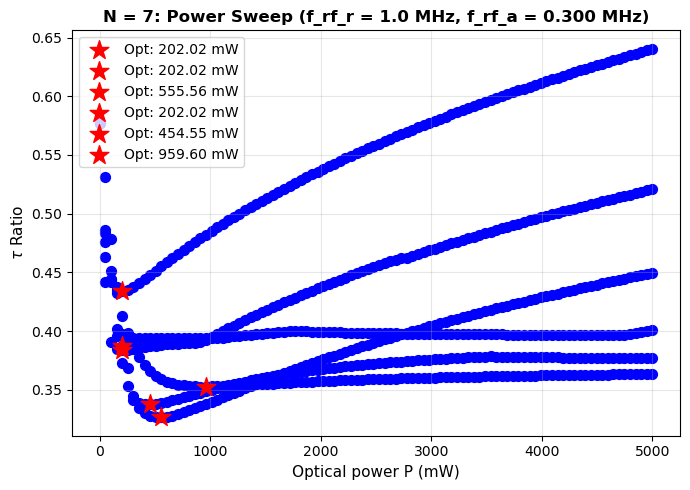


Optimal Powers Summary (f_rf_r = 1.0 MHz):
N = 2: P_opt = 2.020212e-01 W = 202.0212 mW,  Ratio = 0.4338
         f_tweezer/f_rf_a = 1.513014,  f_tweezer/f_rf_r = 0.453904
N = 3: P_opt = 2.020212e-01 W = 202.0212 mW,  Ratio = 0.3836
         f_tweezer/f_rf_a = 1.513014,  f_tweezer/f_rf_r = 0.453904
N = 4: P_opt = 5.555564e-01 W = 555.5564 mW,  Ratio = 0.3266
         f_tweezer/f_rf_a = 2.509045,  f_tweezer/f_rf_r = 0.752714
N = 5: P_opt = 2.020212e-01 W = 202.0212 mW,  Ratio = 0.3877
         f_tweezer/f_rf_a = 1.513014,  f_tweezer/f_rf_r = 0.453904
N = 6: P_opt = 4.545464e-01 W = 454.5464 mW,  Ratio = 0.3379
         f_tweezer/f_rf_a = 2.269517,  f_tweezer/f_rf_r = 0.680855
N = 7: P_opt = 9.595968e-01 W = 959.5968 mW,  Ratio = 0.3528
         f_tweezer/f_rf_a = 3.297530,  f_tweezer/f_rf_r = 0.989259

Stored ratio_a and ratio_r for f_rf_r = 1.0 MHz (length: 6)

Processing f_rf_r = 2.0 MHz, f_rf_a = 0.300 MHz



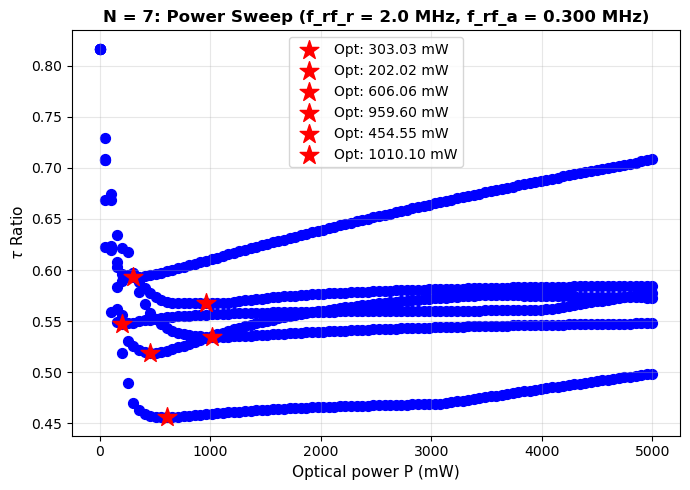


Optimal Powers Summary (f_rf_r = 2.0 MHz):
N = 2: P_opt = 3.030312e-01 W = 303.0312 mW,  Ratio = 0.5928
         f_tweezer/f_rf_a = 1.853054,  f_tweezer/f_rf_r = 0.277958
N = 3: P_opt = 2.020212e-01 W = 202.0212 mW,  Ratio = 0.5476
         f_tweezer/f_rf_a = 1.513014,  f_tweezer/f_rf_r = 0.226952
N = 4: P_opt = 6.060615e-01 W = 606.0615 mW,  Ratio = 0.4559
         f_tweezer/f_rf_a = 2.620612,  f_tweezer/f_rf_r = 0.393092
N = 5: P_opt = 9.595968e-01 W = 959.5968 mW,  Ratio = 0.5677
         f_tweezer/f_rf_a = 3.297530,  f_tweezer/f_rf_r = 0.494630
N = 6: P_opt = 4.545464e-01 W = 454.5464 mW,  Ratio = 0.5191
         f_tweezer/f_rf_a = 2.269517,  f_tweezer/f_rf_r = 0.340428
N = 7: P_opt = 1.010102e+00 W = 1010.1018 mW,  Ratio = 0.5346
         f_tweezer/f_rf_a = 3.383194,  f_tweezer/f_rf_r = 0.507479

Stored ratio_a and ratio_r for f_rf_r = 2.0 MHz (length: 6)

Processing f_rf_r = 3.0 MHz, f_rf_a = 0.300 MHz



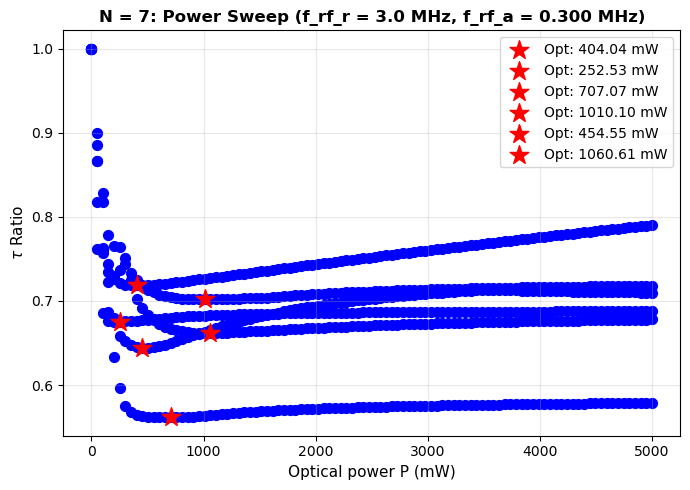


Optimal Powers Summary (f_rf_r = 3.0 MHz):
N = 2: P_opt = 4.040413e-01 W = 404.0413 mW,  Ratio = 0.7185
         f_tweezer/f_rf_a = 2.139722,  f_tweezer/f_rf_r = 0.213972
N = 3: P_opt = 2.525262e-01 W = 252.5262 mW,  Ratio = 0.6755
         f_tweezer/f_rf_a = 1.691600,  f_tweezer/f_rf_r = 0.169160
N = 4: P_opt = 7.070716e-01 W = 707.0716 mW,  Ratio = 0.5616
         f_tweezer/f_rf_a = 2.830584,  f_tweezer/f_rf_r = 0.283058
N = 5: P_opt = 1.010102e+00 W = 1010.1018 mW,  Ratio = 0.7020
         f_tweezer/f_rf_a = 3.383194,  f_tweezer/f_rf_r = 0.338319
N = 6: P_opt = 4.545464e-01 W = 454.5464 mW,  Ratio = 0.6439
         f_tweezer/f_rf_a = 2.269517,  f_tweezer/f_rf_r = 0.226952
N = 7: P_opt = 1.060607e+00 W = 1060.6068 mW,  Ratio = 0.6620
         f_tweezer/f_rf_a = 3.466743,  f_tweezer/f_rf_r = 0.346674

Stored ratio_a and ratio_r for f_rf_r = 3.0 MHz (length: 6)

All data collected!
all_ratio_a keys: ['1.0MHz', '2.0MHz', '3.0MHz']
all_ratio_r keys: ['1.0MHz', '2.0MHz', '3.0MHz']


In [185]:
# --- Create RF frequency lists ---
f_rf_r_list = [1e6, 2e6, 3e6]
f_rf_a_list = [0.3e6, 0.3e6, 0.3e6]  # Match each f_rf_r with corresponding f_rf_a

print(f"f_rf_r_list: {f_rf_r_list}")
print(f"f_rf_a_list: {f_rf_a_list}")

# Dictionary to store all ratios by RF frequency
all_ratio_a = {}
all_ratio_r = {}

# Loop over each RF frequency pair
for f_idx, (f_rf_r, f_rf_a) in enumerate(zip(f_rf_r_list, f_rf_a_list)):
    print(f"\n{'='*80}")
    print(f"Processing f_rf_r = {f_rf_r/1e6:.1f} MHz, f_rf_a = {f_rf_a/1e6:.3f} MHz")
    print(f"{'='*80}\n")
    
    # --- Extract and plot for each N ---
    fig, ax = plt.subplots(figsize=(7, 5))
    
    N_values = np.arange(2, 8)  # Process all N values from 2 to 7
    w0 = 1e-6
    P_list = np.linspace(1e-6, 5, 100)  # optical powers
    
    optimal_powers_W = []
    optimal_powers_mW = []
    optimal_ratios = []
    ratio_a = []
    ratio_r = []
    
    for idx, N in enumerate(N_values):
        # --- Run power sweep for this N with current RF frequencies ---
        power_results = []
        for P in P_list:
            winners = run_optimal_mode_selection_tweezed_only(
                omega_tweezer,
                linewidths,
                omega_res,
                m,
                mode_calc_r,
                N,
                f_rf_r,
                f_rf_a,
                P,
                w0,
                max_tweezed=1
            )
            power_results.append(winners)
        
        x_tweezed = []
        y_tweezed = []
        
        # Extract scores from power_results for this N
        for P_opt, winners in zip(P_list, power_results):
            if not winners:
                continue
            winner = winners[0]
            
            if len(winner) >= 3:
                tweezed_ion = winner[0]
                score = winner[2]
            else:
                continue
            
            if tweezed_ion is None:
                continue
            
            x_tweezed.append(P_opt)
            y_tweezed.append(abs(score))
        
        x_tweezed = np.array(x_tweezed)
        y_tweezed = np.array(y_tweezed)
        
        untweezed_ref = untweezed_winners[N-2]
        
        if len(y_tweezed) > 0:
            ratio = untweezed_ref / y_tweezed
            opt_idx = np.argmin(ratio)
            
            opt_power_W = x_tweezed[opt_idx]
            opt_power_mW = opt_power_W * 1e3
            opt_ratio = ratio[opt_idx]
            
            optimal_powers_W.append(opt_power_W)
            optimal_powers_mW.append(opt_power_mW)
            optimal_ratios.append(opt_ratio)
            
            # Calculate tweezer frequency ratios for this N
            U = potential(omega_tweezer, linewidths, omega_res, opt_power_W, w0)
            tweezer_f = omega_tweezer_r(U, w0, m) / (2.0 * pi)
            
            tweezer_to_rf_a_ratio = tweezer_f / f_rf_a
            tweezer_to_rf_r_ratio = tweezer_f / f_rf_r
            
            ratio_a.append(tweezer_to_rf_a_ratio)
            ratio_r.append(tweezer_to_rf_r_ratio)
            
            # Plot on single axis
            ax.scatter(x_tweezed * 1e3, ratio, marker='o', color='blue', s=50)
            ax.set_xlabel("Optical power P (mW)", fontsize=11)
            ax.set_ylabel(r"$\tau$ Ratio", fontsize=11)
            ax.set_title(f"N = {N}: Power Sweep (f_rf_r = {f_rf_r/1e6:.1f} MHz, f_rf_a = {f_rf_a/1e6:.3f} MHz)", 
                        fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)
            
            ax.scatter(opt_power_mW, opt_ratio, color='red', s=200, marker='*', 
                      zorder=5, label=f'Opt: {opt_power_mW:.2f} mW')
            ax.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # --- Print summary for this RF frequency set ---
    optimal_powers_W = np.array(optimal_powers_W)
    optimal_powers_mW = np.array(optimal_powers_mW)
    optimal_ratios = np.array(optimal_ratios)
    ratio_a = np.array(ratio_a)
    ratio_r = np.array(ratio_r)
    
    print(f"\nOptimal Powers Summary (f_rf_r = {f_rf_r/1e6:.1f} MHz):")
    print("=" * 80)
    for N, P_W, P_mW, ratio, r_a, r_r in zip(N_values, optimal_powers_W, optimal_powers_mW, optimal_ratios, ratio_a, ratio_r):
        print(f"N = {N}: P_opt = {P_W:.6e} W = {P_mW:.4f} mW,  Ratio = {ratio:.4f}")
        print(f"         f_tweezer/f_rf_a = {r_a:.6f},  f_tweezer/f_rf_r = {r_r:.6f}")
    print("=" * 80)
    
    # Store ratios in dictionary by RF frequency
    freq_key = f"{f_rf_r/1e6:.1f}MHz"
    all_ratio_a[freq_key] = ratio_a
    all_ratio_r[freq_key] = ratio_r
    print(f"\nStored ratio_a and ratio_r for f_rf_r = {f_rf_r/1e6:.1f} MHz (length: {len(ratio_a)})")

print(f"\n{'='*80}")
print("All data collected!")
print(f"all_ratio_a keys: {list(all_ratio_a.keys())}")
print(f"all_ratio_r keys: {list(all_ratio_r.keys())}")
print(f"{'='*80}")

In [186]:
# Print out all frequency ratios organized by N

print("\n" + "="*100)
print("FREQUENCY RATIOS SUMMARY: f_tweezer / f_rf for each N and RF frequency")
print("="*100)

# Get N values
N_values = np.arange(2, 8)

# Print header
print(f"\n{'N':<5} {'f_rf_r (MHz)':<20} {'Ratio f_tw/f_rf_r':<25} {'f_rf_a (MHz)':<20} {'Ratio f_tw/f_rf_a':<25}")
print("-"*100)

# Loop through each N
for n_idx, N in enumerate(N_values):
    print(f"\n{N:<5}", end="")
    
    # Loop through each RF frequency set
    freq_idx = 0
    for freq_key in ["1.0MHz", "2.0MHz", "3.0MHz"]:
        if freq_idx > 0:
            print(f"\n{'':<5}", end="")  # Indent for continuation lines
        
        # Extract the RF frequencies from the key
        f_rf_r_val = float(freq_key.split("MHz")[0]) * 1e6
        f_rf_a_val = f_rf_r_val / 10  # Since f_rf_a = 0.3e6 and f_rf_r varies
        
        # Get ratios
        ratio_r_val = all_ratio_r[freq_key][n_idx]
        ratio_a_val = all_ratio_a[freq_key][n_idx]
        
        print(f"{f_rf_r_val/1e6:<20.1f} {ratio_r_val:<25.6f} {f_rf_a_val/1e6:<20.3f} {ratio_a_val:<25.6f}", end="")
        
        freq_idx += 1

print("\n" + "="*100 + "\n")

# Also print in table format by RF frequency
print("\n" + "="*100)
print("ORGANIZED BY RF FREQUENCY")
print("="*100)

for freq_key in ["1.0MHz", "2.0MHz", "3.0MHz"]:
    f_rf_r_val = float(freq_key.split("MHz")[0]) * 1e6
    f_rf_a_val = 0.3e6
    
    print(f"\n{'─'*100}")
    print(f"RF Frequency Set: f_rf_r = {f_rf_r_val/1e6:.1f} MHz, f_rf_a = {f_rf_a_val/1e6:.3f} MHz")
    print(f"{'─'*100}")
    print(f"{'N':<8} {'f_tweezer/f_rf_r':<25} {'f_tweezer/f_rf_a':<25}")
    print("-"*60)
    
    for n_idx, N in enumerate(N_values):
        ratio_r_val = all_ratio_r[freq_key][n_idx]
        ratio_a_val = all_ratio_a[freq_key][n_idx]
        print(f"{N:<8} {ratio_r_val:<25.6f} {ratio_a_val:<25.6f}")

print("\n" + "="*100 + "\n")


FREQUENCY RATIOS SUMMARY: f_tweezer / f_rf for each N and RF frequency

N     f_rf_r (MHz)         Ratio f_tw/f_rf_r         f_rf_a (MHz)         Ratio f_tw/f_rf_a        
----------------------------------------------------------------------------------------------------

2    1.0                  0.453904                  0.100                1.513014                 
     2.0                  0.277958                  0.200                1.853054                 
     3.0                  0.213972                  0.300                2.139722                 
3    1.0                  0.453904                  0.100                1.513014                 
     2.0                  0.226952                  0.200                1.513014                 
     3.0                  0.169160                  0.300                1.691600                 
4    1.0                  0.752714                  0.100                2.509045                 
     2.0                  0.3930